In [52]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from epimodels.continuous.models import SISLogistic
from epimodels.fitting import (
    Dataset,
    DataSeries,
    ParameterSpec,
    ModelFitter,
    FittingResult,
    fit_model,
    SumOfSquaredErrors,
    WeightedSSE,
    PoissonLikelihood,
    NegativeBinomialLikelihood,
    NormalLikelihood,
    HuberLoss,
    ScipyOptimizer,
    MultiStartOptimizer,
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [53]:
df = pd.read_csv("dengue_data_logistic.csv")

df = df.sort_values("data_iniSE")

times = np.arange(len(df))

observed_I = df["casos_est"].values

TOTAL_POPULATION = df["pop"].iloc[0]
INITIAL_INFECTED = observed_I[0]
INITIAL_SUSCEPTIBLE = TOTAL_POPULATION - INITIAL_INFECTED

In [54]:
model = SISLogistic()
dataset = Dataset(model)

dataset.register(
    name='infected',
    values=observed_I,
    times=times,
    state_variable='I',
)

validation_result = dataset.validate(total_population=TOTAL_POPULATION)

print(f"Dataset valid: {validation_result.is_valid}")
print(f"Time range: {dataset.time_range}")
print(dataset)

Dataset valid: True
Time range: (0.0, 103.0)
Dataset(n_series=1, variables=['I'], time_range=(0.0, 103.0))


In [55]:
param_specs = [
    ParameterSpec(
        name='beta',
        bounds=(0.1, 1.0),
        initial=0.7,
    ),
    ParameterSpec(
        name='gamma',
        bounds=(0.01, 0.5),
        initial=0.3,
    ),
    ParameterSpec(
        name='r',
        bounds=(0.01, 0.5),
        initial=0.4,
    ),
    ParameterSpec(
        name='k',
        bounds=(1000, 20000),
        initial=5000,
    ),
]

print("Parameters to fit:")
for spec in param_specs:
    print(f"  {spec.name}: bounds={spec.bounds}, initial={spec.initial}")

Parameters to fit:
  beta: bounds=(0.1, 1.0), initial=0.7
  gamma: bounds=(0.01, 0.5), initial=0.3
  r: bounds=(0.01, 0.5), initial=0.4
  k: bounds=(1000, 20000), initial=5000


In [59]:
fitter = ModelFitter(
    model=model,
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED,
    optimizer=ScipyOptimizer(method='L-BFGS-B', max_iterations=200),
)

result = fitter.fit()

print("\n" + "="*50)
print("FITTING RESULTS")
print("="*50)
print(f"Convergence: {result.convergence}")
print(f"Number of evaluations: {result.n_evaluations}")
print(f"Final loss: {result.best_loss:.2f}")

print("\nFitted parameters:")

for param, value in result.best_params.items():

    print(f"  {param}: {value:.4f}")


FITTING RESULTS
Convergence: True
Number of evaluations: 485
Final loss: 218779.96

Fitted parameters:
  beta: 0.4787
  gamma: 0.5000
  r: 0.2448
  k: 1000.0000


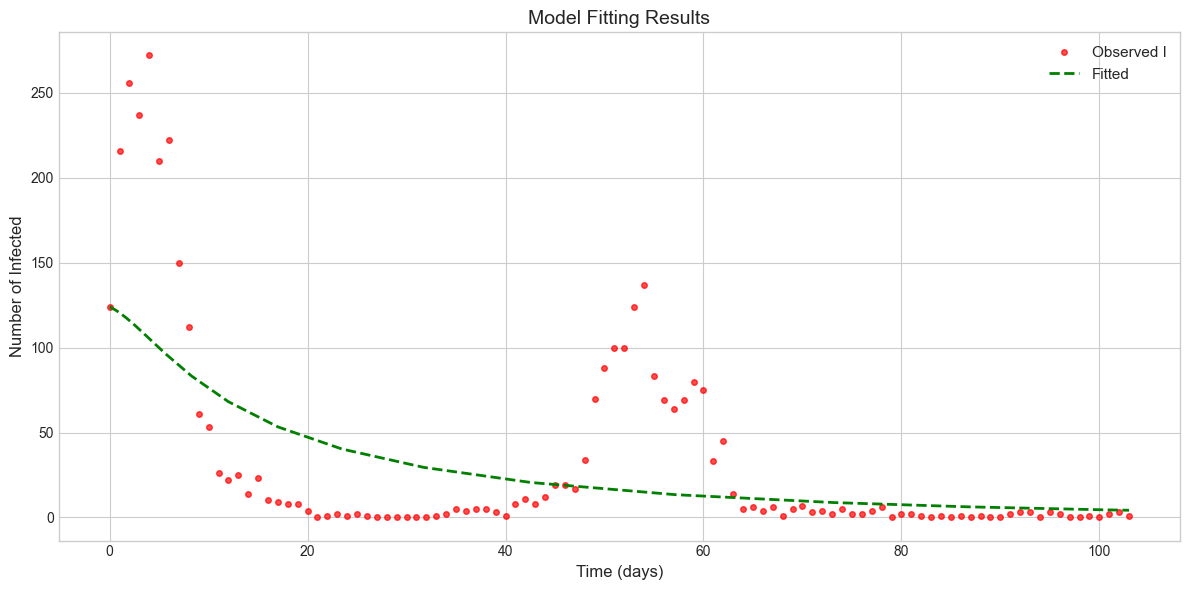

In [60]:
fitted_model = result.fitted_model

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(times, observed_I, 'ro', label='Observed I', markersize=4, alpha=0.7)

if fitted_model is not None and fitted_model.traces:
    ax.plot(fitted_model.traces['time'], fitted_model.traces['I'], 
            'g--', label='Fitted', linewidth=2)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Number of Infected', fontsize=12)
ax.set_title('Model Fitting Results', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()